# 01 — Data Understanding and Persistence Baseline

This Phase 1 notebook documents the verified data structure, training-only normalization statistics, and a persistence reference. Each sample contains 336 historical hourly observations across 12 input variables; the task is to predict the next 48 hours of specific discharge. Evaluation uses the official validation split. No new 80/20 split is created. Persistence is the reference model before training neural experts.

In [1]:
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support launching Jupyter with either the repository root or notebooks/ as its working directory.
ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'Input' / 'metadata.json').is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('Could not locate repository root containing Input/metadata.json')

INPUT_DIR = ROOT / 'Input'
OUTPUT_DIR = ROOT / 'outputs'
TRAIN_H5 = INPUT_DIR / 'train-001.h5'
TEST_H5 = INPUT_DIR / 'test.h5'

## Metadata summary

The compact summary below comes from the supplied metadata file. The channel table in the next section makes the input order explicit.

In [2]:
with (INPUT_DIR / 'metadata.json').open(encoding='utf-8') as file:
    metadata = json.load(file)

metadata_summary = pd.DataFrame([{
    'history_hours': metadata['history_hours'],
    'forecast_hours': metadata['forecast_hours'],
    'interval_hours': metadata['interval_hours'],
    'target': metadata['target'],
    'target_channel': metadata['target_channel'],
    'train_samples': metadata['samples'].get('train'),
    'validation_samples': metadata['samples'].get('validation'),
    'test_samples': metadata['samples'].get('test'),
}])
display(metadata_summary)
print('Channel names in order:', ', '.join(channel['name'] for channel in metadata['channels']))

,history_hours,forecast_hours,interval_hours,target,target_channel,train_samples,validation_samples,test_samples
0,336,48,1,specific_discharge,11,254000,18142,27983


Channel names in order: convective_fraction, longwave_radiation, potential_energy, potential_evaporation, pressure, shortwave_radiation, specific_humidity, temperature, total_precipitation, wind_u, wind_v, specific_discharge


## Dataset structure verification

HDF5 dataset metadata is inspected without materializing the full arrays. The validation samples used later are read individually in a small selection.

In [3]:
with h5py.File(TRAIN_H5, 'r') as file:
    train_structure = {key: file[key].shape for key in file.keys()}
with h5py.File(TEST_H5, 'r') as file:
    test_keys = list(file.keys())
    test_structure = {key: file[key].shape for key in ('X', 'basin_id')}

print('train-001.h5 keys and shapes:', train_structure)
print('test.h5 keys:', test_keys)
print('test.h5 shapes:', test_structure)

train-001.h5 keys and shapes: {'X': (272142, 336, 12), 'basin_id': (272142,), 'split': (272142,), 'y': (272142, 48), 'y_aux': (272142, 48, 11)}
test.h5 keys: ['X', 'basin_id']
test.h5 shapes: {'X': (27983, 336, 12), 'basin_id': (27983,)}


## Input variables

Channel 11 is the historical target discharge. The other channels are meteorological or hydrometeorological predictors.

In [4]:
channels = sorted(metadata['channels'], key=lambda channel: channel['index'])
variables = pd.DataFrame([{
    'channel': channel['index'],
    'variable': channel['name'],
    'role': ('Historical target discharge' if channel['index'] == metadata['target_channel']
             else 'Meteorological/hydrometeorological predictor'),
} for channel in channels])
display(variables)

,channel,variable,role
0,0,convective_fraction,Meteorological/hydrometeorological predictor
1,1,longwave_radiation,Meteorological/hydrometeorological predictor
2,2,potential_energy,Meteorological/hydrometeorological predictor
3,3,potential_evaporation,Meteorological/hydrometeorological predictor
4,4,pressure,Meteorological/hydrometeorological predictor
5,5,shortwave_radiation,Meteorological/hydrometeorological predictor
6,6,specific_humidity,Meteorological/hydrometeorological predictor
7,7,temperature,Meteorological/hydrometeorological predictor
8,8,total_precipitation,Meteorological/hydrometeorological predictor
9,9,wind_u,Meteorological/hydrometeorological predictor


## Training normalization statistics

These precomputed statistics were calculated using ONLY the training split. This notebook reads the saved values and does not recompute them.

In [5]:
with (OUTPUT_DIR / 'train_stats.json').open(encoding='utf-8') as file:
    train_stats = json.load(file)

x_stats = pd.DataFrame({
    'channel': [channel['name'] for channel in channels],
    'mean': train_stats['x']['mean'],
    'std': train_stats['x']['std'],
})
display(x_stats)
display(pd.DataFrame([{'target': metadata['target'],
                       'mean': train_stats['y']['mean'],
                       'std': train_stats['y']['std']}]))

,channel,mean,std
0,convective_fraction,0.060951,0.205333
1,longwave_radiation,313.379897,64.261232
2,potential_energy,204.519208,500.825597
3,potential_evaporation,0.205742,0.270320
4,pressure,93545.672269,8089.386639
5,shortwave_radiation,199.869451,265.289247
6,specific_humidity,0.007676,0.004390
7,temperature,13.226768,9.861157
8,total_precipitation,0.132268,0.670326
9,wind_u,1.003500,3.063596


,target,mean,std
0,specific_discharge,0.066194,0.161164


## Example validation trajectories

The following figures show three validation examples. Historical discharge is limited to the final 96 hours for readability; future observations and the 48-hour persistence forecast are shown after the forecast origin.

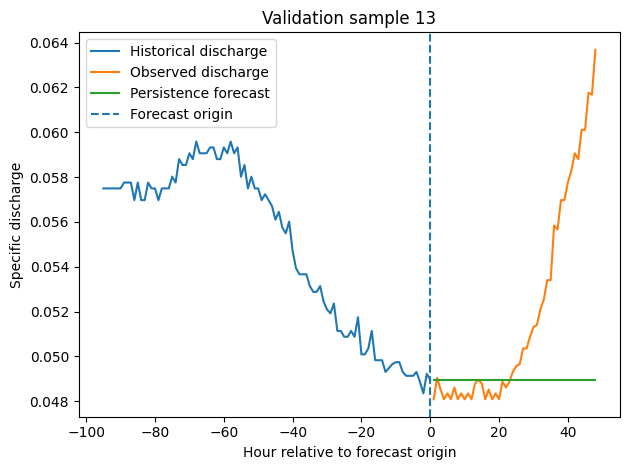

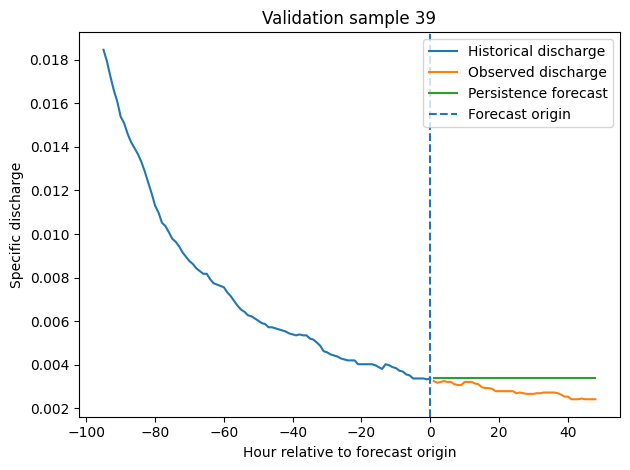

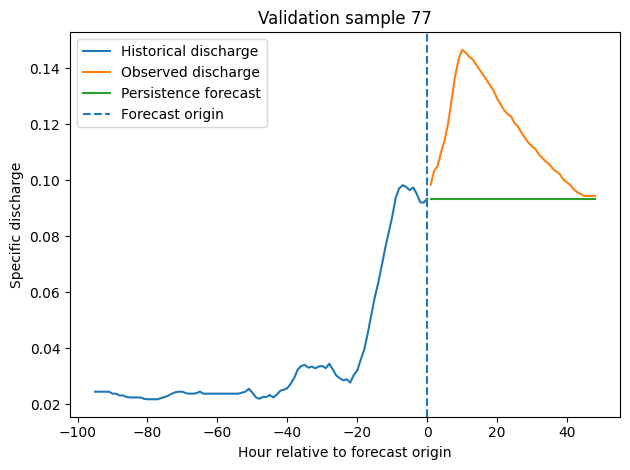

In [6]:
with h5py.File(TRAIN_H5, 'r') as file:
    validation_indices = np.flatnonzero(file['split'][:] == 1)[:3]
    for sample_index in validation_indices:
        history = file['X'][sample_index, -96:, metadata['target_channel']]
        future = file['y'][sample_index]
        persistence = np.repeat(history[-1], metadata['forecast_hours'])

        history_hours = np.arange(-len(history) + 1, 1)
        forecast_hours = np.arange(1, metadata['forecast_hours'] + 1)
        fig, ax = plt.subplots()
        ax.plot(history_hours, history, label='Historical discharge')
        ax.plot(forecast_hours, future, label='Observed discharge')
        ax.plot(forecast_hours, persistence, label='Persistence forecast')
        ax.axvline(0, linestyle='--', label='Forecast origin')
        ax.set(title=f'Validation sample {int(sample_index)}',
               xlabel='Hour relative to forecast origin', ylabel='Specific discharge')
        ax.legend()
        fig.tight_layout()
        plt.show()

## Persistence baseline results

Persistence repeats the last observed historical discharge value across all 48 forecast hours. These validation results are the reference for comparison with learned models; the baseline is reported without a qualitative rating.

In [7]:
with (OUTPUT_DIR / 'persistence_validation.json').open(encoding='utf-8') as file:
    persistence_results = json.load(file)

display(pd.DataFrame([persistence_results['global']]))
print('Split:', persistence_results['split'])
print('Validation samples:', persistence_results['n_samples'])

,mae,rmse,nse
0,0.024464,0.137859,0.354547


Split: validation
Validation samples: 18142


## Horizon-dependent baseline error

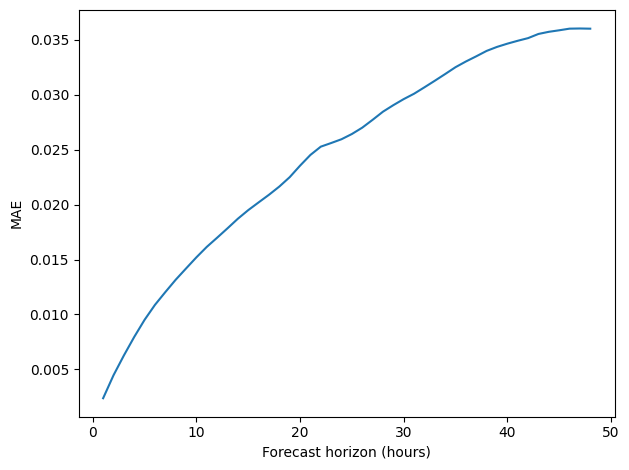

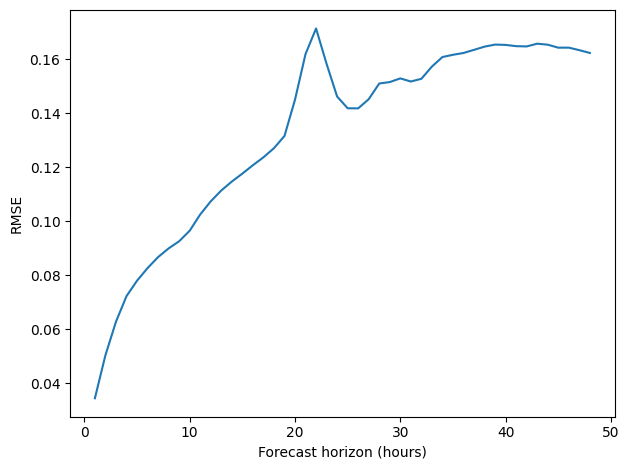

In [8]:
horizons = np.arange(1, len(persistence_results['per_horizon']['mae']) + 1)

fig, ax = plt.subplots()
ax.plot(horizons, persistence_results['per_horizon']['mae'])
ax.set(xlabel='Forecast horizon (hours)', ylabel='MAE')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(horizons, persistence_results['per_horizon']['rmse'])
ax.set(xlabel='Forecast horizon (hours)', ylabel='RMSE')
fig.tight_layout()
plt.show()

## Phase 1 conclusion

The dataset loader and stored structure have been verified, normalization statistics are derived from the training split only, and persistence has been established on the official validation split. The next stage is to train and evaluate independent neural experts: LSTM, GRU, LSTM Seq2Seq with Attention, and Informer. Router development follows the expert comparisons in a later phase.